# Encoder-based next-frame prediction

Amortized encoder `E(I)->r`, decoder `D`, ConvGRU on stored latents.

**Stage 1** — train AE on shuffled frames (recon MSE). Freeze it afterward.

**Stage 2** — ConvGRU takes **two consecutive latents** and predicts the next one.
Teacher-force 1-step windows, plus autoregressive rollout that feeds its own predictions back in.

No online settle, no per-frame manual SGD.


In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "torch:", torch.__version__)


device: cpu torch: 2.13.0


In [56]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
raw = datasets.MovingMNIST(root="./data", split=None, download=True)


def prep_seq(seq):
    x = seq.float() / 255.0
    if x.ndim == 3:
        x = x.unsqueeze(1)
    return torch.stack([fr - fr.mean() for fr in x], dim=0)


N_TRAIN, N_VAL = 64, 8
train_seqs = [prep_seq(raw[i]) for i in range(N_TRAIN)]
val_seqs = [prep_seq(raw[N_TRAIN + i]) for i in range(N_VAL)]
T = train_seqs[0].shape[0]
print(f"{N_TRAIN} train / {N_VAL} val sequences, T={T}, {tuple(train_seqs[0].shape)}")

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")



100.0%


64 train / 8 val sequences, T=20, (20, 1, 64, 64)


define encoder and decoder

In [57]:
encoder = nn.Conv2d(1, 32, 4, stride=2, padding=1).to(device)
decoder = nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1).to(device)

define hyperparameters etc

In [58]:
ae_epochs = 100
ae_lr = 1e-3
ae_batch_size = 32

train_frames = torch.cat(train_seqs, dim=0)  # (N*T, 1, 64, 64)
val_frames = torch.cat(val_seqs, dim=0)

train_loader = DataLoader(TensorDataset(train_frames), batch_size=ae_batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_frames), batch_size=ae_batch_size, shuffle=False)

ae_optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()), lr=ae_lr
)


In [59]:
def train_loop(num_epochs, encoder, decoder, optimizer, train_loader):
    encoder.train()
    decoder.train()
    for epoch in range(num_epochs):
        total, n = 0.0, 0
        for (I,) in train_loader:
            I = I.to(device)
            I_hat = decoder(F.relu(encoder(I)))
            loss = F.mse_loss(I_hat, I)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item() * I.shape[0]
            n += I.shape[0]
        print(f"Epoch {epoch + 1} recon MSE: {total / n:.6f}")
    return encoder, decoder

In [60]:
def plot_recon(frames, recons, n_show=8):
    frames = frames.detach().cpu()
    recons = recons.detach().cpu()
    n_show = min(n_show, frames.shape[0])
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    if n_show == 1:
        axes = np.array(axes).reshape(2, 1)
    for i in range(n_show):
        axes[0, i].imshow(frames[i, 0], cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, i].set_title(f"True {i + 1}")
        axes[0, i].axis("off")
        axes[1, i].imshow(recons[i, 0], cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, i].set_title(f"Recon {i + 1}")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()


In [61]:
@torch.no_grad()
def val_loop(encoder, decoder, val_loader):
    encoder.eval()
    decoder.eval()
    total, n = 0.0, 0
    last_I, last_hat = None, None
    for (I,) in val_loader:
        I = I.to(device)
        I_hat = decoder(F.relu(encoder(I)))
        total += F.mse_loss(I_hat, I).item() * I.shape[0]
        n += I.shape[0]
        last_I, last_hat = I, I_hat
    mse = total / max(n, 1)
    print(f"Val recon MSE: {mse:.6f}")
    plot_recon(last_I, last_hat)
    return mse 

Encode → ConvGRU (latents) → decode

`E(I) → r`, then ConvGRU takes two consecutive latents and predicts the next. Decoder maps that predicted latent back to a frame. Rollout stays in latent space and only decodes at the end of each predicted step.


In [62]:
class ConvGRUCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3, bias=True):
        super().__init__()
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2
        self.conv_gates = nn.Conv2d(
            in_channels + hidden_channels,
            2 * hidden_channels,
            kernel_size,
            padding=padding,
            bias=bias,
        )
        self.conv_candidate = nn.Conv2d(
            in_channels + hidden_channels,
            hidden_channels,
            kernel_size,
            padding=padding,
            bias=bias,
        )

    def forward(self, x, h_prev):
        gates = self.conv_gates(torch.cat([x, h_prev], dim=1))
        reset, update = gates.chunk(2, dim=1)
        reset = torch.sigmoid(reset)
        update = torch.sigmoid(update)
        candidate = torch.tanh(self.conv_candidate(torch.cat([x, reset * h_prev], dim=1)))
        return (1 - update) * h_prev + update * candidate

    def init_hidden(self, batch_size, height, width):
        return torch.zeros(
            batch_size,
            self.hidden_channels,
            height,
            width,
            device=self.conv_gates.weight.device,
        )


class ConvGRU(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers, kernel_size=3, bias=True):
        super().__init__()
        cells = []
        for i in range(num_layers):
            layer_in = in_channels if i == 0 else hidden_channels
            cells.append(ConvGRUCell(layer_in, hidden_channels, kernel_size, bias))
        self.layers = nn.ModuleList(cells)

    def forward(self, x, hidden=None):
        batch_size, seq_len, _, height, width = x.shape
        if hidden is None:
            hidden_states = [cell.init_hidden(batch_size, height, width) for cell in self.layers]
        else:
            hidden_states = list(hidden)

        outputs = []
        for t in range(seq_len):
            current = x[:, t]
            for i, cell in enumerate(self.layers):
                current = cell(current, hidden_states[i])
                hidden_states[i] = current
            outputs.append(current)
        return torch.stack(outputs, dim=1), hidden_states

class NextFramePredictor(nn.Module):
    def __init__(self, encoder, decoder, hidden_channels, num_layers, kernel_size=3):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.latent_channels = encoder.out_channels
        self.gru = ConvGRU(self.latent_channels * 2, hidden_channels, num_layers, kernel_size)
        self.head = nn.Conv2d(hidden_channels, self.latent_channels, kernel_size=1)

    def encode(self, frames):
        lead = frames.shape[:-3]
        x = frames.reshape(-1, *frames.shape[-3:])
        r = F.relu(self.encoder(x))
        return r.view(*lead, *r.shape[1:])

    def decode(self, r):
        lead = r.shape[:-3]
        x = r.reshape(-1, *r.shape[-3:])
        frames = self.decoder(x)
        return frames.view(*lead, 1, *frames.shape[-2:])

    def _predict_from_pairs(self, pairs, hidden=None):
        out, hidden = self.gru(pairs, hidden)
        b, t, h_ch, h, w = out.shape
        r_next = F.relu(self.head(out.reshape(b * t, h_ch, h, w)))
        return r_next.view(b, t, self.latent_channels, h, w), hidden

    def predict_latent(self, r_seq, teacher_force=True):
        if teacher_force:
            pairs = torch.cat([r_seq[:, :-2], r_seq[:, 1:-1]], dim=2)
            preds, _ = self._predict_from_pairs(pairs)
            return preds
        return self.rollout(r_seq[:, 0], r_seq[:, 1], n_steps=r_seq.shape[1] - 2)

    def rollout(self, r0, r1, n_steps, hidden=None):
        preds = []
        r_prev, r_curr = r0, r1
        for _ in range(n_steps):
            pair = torch.cat([r_prev, r_curr], dim=1).unsqueeze(1)
            r_next, hidden = self._predict_from_pairs(pair, hidden)
            r_next = r_next[:, 0]
            preds.append(r_next)
            r_prev, r_curr = r_curr, r_next
        return torch.stack(preds, dim=1)

    def forward(self, frames, teacher_force=True):
        r = self.encode(frames)
        r_hat = self.predict_latent(r, teacher_force=teacher_force)
        return self.decode(r_hat)


Hyper parameters/config for temporal nn

In [63]:
temporal_epochs = 100
temporal_lr = 1e-3
temporal_batch_size = 8
context = 2
unroll_steps = 8 

num_layers = 2
hidden_channels = 64
kernel_size = 3

model = NextFramePredictor(encoder, decoder, hidden_channels, num_layers, kernel_size).to(device)
temporal_optimizer = torch.optim.Adam(
    [p for n, p in model.named_parameters() if not n.startswith("encoder.") and not n.startswith("decoder.")],
    lr=temporal_lr,
)


Freeze AE. Each batch: encode frames → ConvGRU predicts next latent from the previous two → decode. Loss on both latents and decoded pixels. Teacher-force + autoregressive rollout.


In [ ]:
def plot_rollout(true_frames, pred_frames, context=2, n_show=10):
    true_frames = true_frames.detach().cpu()
    pred_frames = pred_frames.detach().cpu()
    t_show = min(n_show, true_frames.shape[0])
    shown_pred = torch.cat([true_frames[:context], pred_frames], dim=0)[:t_show]
    fig, axes = plt.subplots(2, t_show, figsize=(1.4 * t_show, 3.2))
    if t_show == 1:
        axes = np.array(axes).reshape(2, 1)
    for i in range(t_show):
        axes[0, i].imshow(true_frames[i, 0], cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, i].set_title(f"true t={i}")
        axes[0, i].axis("off")
        axes[1, i].imshow(shown_pred[i, 0], cmap="gray", vmin=-0.5, vmax=0.5)
        label = "ctx" if i < context else "pred"
        axes[1, i].set_title(f"{label} t={i}")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()


def train_temporal(model, train_seqs, optimizer, num_epochs, batch_size, unroll_steps):
    for p in model.encoder.parameters():
        p.requires_grad = False
    for p in model.decoder.parameters():
        p.requires_grad = False
    model.encoder.eval()
    model.decoder.eval()

    frames_all = torch.stack(train_seqs)
    loader = DataLoader(TensorDataset(frames_all), batch_size=batch_size, shuffle=True)

    model.gru.train()
    model.head.train()
    for epoch in range(num_epochs):
        total_tf, total_ar, n = 0.0, 0.0, 0
        for (frames,) in loader:
            frames = frames.to(device)
            t_len = frames.shape[1]
            n_ar = min(unroll_steps, t_len - 2)

            with torch.no_grad():
                r = model.encode(frames)

            r_hat_tf = model.predict_latent(r, teacher_force=True)
            I_hat_tf = model.decode(r_hat_tf)
            loss_tf = F.mse_loss(r_hat_tf, r[:, 2:]) + F.mse_loss(I_hat_tf, frames[:, 2:])

            r_hat_ar = model.rollout(r[:, 0], r[:, 1], n_steps=n_ar)
            I_hat_ar = model.decode(r_hat_ar)
            loss_ar = F.mse_loss(r_hat_ar, r[:, 2:2 + n_ar]) + F.mse_loss(I_hat_ar, frames[:, 2:2 + n_ar])

            loss = loss_tf + loss_ar
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            b = frames.shape[0]
            total_tf += loss_tf.item() * b
            total_ar += loss_ar.item() * b
            n += b
        print(
            f"Epoch {epoch + 1}  teacher-force MSE: {total_tf / n:.6f}  "
            f"rollout MSE ({n_ar} steps): {total_ar / n:.6f}"
        )
    return model


@torch.no_grad()
def val_temporal(model, val_seqs, context=2):
    model.eval()
    frames = torch.stack([s.to(device) for s in val_seqs], dim=0)
    I_pred = model(frames, teacher_force=False)
    pixel_mse = F.mse_loss(I_pred, frames[:, context:]).item()
    r = model.encode(frames)
    r_pred = model.predict_latent(r, teacher_force=False)
    latent_mse = F.mse_loss(r_pred, r[:, context:]).item()
    print(f"Val rollout latent MSE: {latent_mse:.6f}  pixel MSE: {pixel_mse:.6f}")
    plot_rollout(frames[0], I_pred[0], context=context)
    return latent_mse, pixel_mse


Epoch 1 recon MSE: 0.038119
Epoch 2 recon MSE: 0.007231
Epoch 3 recon MSE: 0.003508
Epoch 4 recon MSE: 0.002275
Epoch 5 recon MSE: 0.001627
Epoch 6 recon MSE: 0.001228
Epoch 7 recon MSE: 0.000969
Epoch 8 recon MSE: 0.000786
Epoch 9 recon MSE: 0.000652
Epoch 10 recon MSE: 0.000550
Epoch 11 recon MSE: 0.000469
Epoch 12 recon MSE: 0.000405
Epoch 13 recon MSE: 0.000352
Epoch 14 recon MSE: 0.000309
Epoch 15 recon MSE: 0.000272
Epoch 16 recon MSE: 0.000241
Epoch 17 recon MSE: 0.000215
Epoch 18 recon MSE: 0.000192
Epoch 19 recon MSE: 0.000172
Epoch 20 recon MSE: 0.000155
Epoch 21 recon MSE: 0.000140
Epoch 22 recon MSE: 0.000127
Epoch 23 recon MSE: 0.000115
Epoch 24 recon MSE: 0.000105
Epoch 25 recon MSE: 0.000096
Epoch 26 recon MSE: 0.000088
Epoch 27 recon MSE: 0.000081
Epoch 28 recon MSE: 0.000075
Epoch 29 recon MSE: 0.000070
Epoch 30 recon MSE: 0.000065
Epoch 31 recon MSE: 0.000061
Epoch 32 recon MSE: 0.000057
Epoch 33 recon MSE: 0.000053
Epoch 34 recon MSE: 0.000050
Epoch 35 recon MSE: 0.0

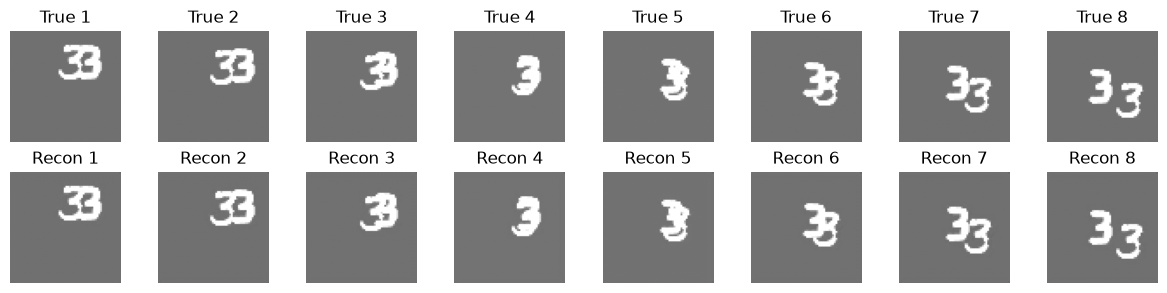

Epoch 1  teacher-force MSE: 0.063990  rollout MSE (8 steps): 0.069266
Epoch 2  teacher-force MSE: 0.048068  rollout MSE (8 steps): 0.062306
Epoch 3  teacher-force MSE: 0.042209  rollout MSE (8 steps): 0.060217
Epoch 4  teacher-force MSE: 0.039456  rollout MSE (8 steps): 0.059606
Epoch 5  teacher-force MSE: 0.038975  rollout MSE (8 steps): 0.059580
Epoch 6  teacher-force MSE: 0.043395  rollout MSE (8 steps): 0.060992
Epoch 7  teacher-force MSE: 0.038832  rollout MSE (8 steps): 0.058433
Epoch 8  teacher-force MSE: 0.036993  rollout MSE (8 steps): 0.056962
Epoch 9  teacher-force MSE: 0.036227  rollout MSE (8 steps): 0.055741
Epoch 10  teacher-force MSE: 0.035562  rollout MSE (8 steps): 0.055212
Epoch 11  teacher-force MSE: 0.035133  rollout MSE (8 steps): 0.054672
Epoch 12  teacher-force MSE: 0.035045  rollout MSE (8 steps): 0.055744
Epoch 13  teacher-force MSE: 0.035113  rollout MSE (8 steps): 0.055479
Epoch 14  teacher-force MSE: 0.034511  rollout MSE (8 steps): 0.054551
Epoch 15  teach

In [ ]:
def main():
    train_loop(ae_epochs, encoder, decoder, ae_optimizer, train_loader)
    val_loop(encoder, decoder, val_loader)
    train_temporal(
        model, train_seqs, temporal_optimizer,
        temporal_epochs, temporal_batch_size, unroll_steps,
    )
    val_temporal(model, val_seqs, context=context)


if __name__ == "__main__":
    main()
